In [1]:
import os
import json
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
from src.visualize import plot_same_cells_across_env


In [2]:
%load_ext autoreload
%autoreload 2

## Paper visualization - can ignore this

In [77]:
# Cell 1: imports + helpers
import math

from scipy.stats import mannwhitneyu, kruskal
from src.evaluation.module_eval import top_cells_grid_scales

# Cell 2: compact "me" scale function
def get_grid_scales_me_cm(dt, model="tpc", n_cells=80, h=1.6):
    path = f"../results/{model}/{dt}"
    sacs = np.load(f"{path}/sac.npy")[:n_cells]                    # sorted by grid score
    scores = np.load(f"{path}/grid_scores.npy")
    unsrt_scores = np.load(f"{path}/unsrt_grid_scores.npy")

    scales_px = np.array([
        get_grid_scale(find_local_maxima(sac), find_global_maxima(sac), method="average")
        for sac in sacs
    ], dtype=float)

    rate_map_h = (sacs[0].shape[0] + 1) / 2
    bin_size_m = h / rate_map_h
    scales_cm = scales_px * bin_size_m * 100.0
    return scales_cm, scales_px, scores, unsrt_scores, sacs

# Cell 3: helpers
def _to_list(x):
    if isinstance(x, list): return x
    if x is None or (isinstance(x, float) and np.isnan(x)): return None
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except Exception: return None
    return None

def _module_counts(ng, n_module, module_fracs):
    if module_fracs is None:
        if ng % n_module != 0:
            raise ValueError(f"Ng={ng} not divisible by n_module={n_module} and module_fracs missing.")
        return [ng // n_module] * n_module
    fr = np.asarray(module_fracs, dtype=float)
    fr = fr / fr.sum()
    counts = np.floor(fr * ng).astype(int)
    counts[-1] = ng - counts[:-1].sum()
    return counts.tolist()

def module_index_sorted_by_score(dt, model="tpc", n_cells=80):
    path = f"../results/{model}/{dt}"
    cfg = json.load(open(f"{path}/configs.json", "r"))
    unsrt_scores = np.load(f"{path}/unsrt_grid_scores.npy")
    sort_idx = np.argsort(unsrt_scores)[::-1]

    ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)
    counts = _module_counts(ng, n_module, fracs)

    module_of_orig = np.empty(ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s+c] = m
        s += c

    return module_of_orig[sort_idx][:n_cells], cfg

def p_to_stars(p):
    if not np.isfinite(p): return "n/a"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"



In [90]:
csv_path = "../results/tpc/multi_module_runs_after_2026-03-14.csv"
runs_df = pd.read_csv(csv_path)
runs_df = runs_df[runs_df["run"].isin([
    "Apr-05-2026-23-13-47",  # both: diff inf_lr + block wr
    "Apr-11-2026-20-05-03",  # diff inf_lr only
    "Apr-12-2026-09-50-39",  # block wr only
])].copy()


n_cells = 64
cell_rows = []
run_stats = []

for _, row in runs_df.iterrows():
    dt = row["run"]
    mod_idx, cfg = module_index_sorted_by_score(dt, model="tpc", n_cells=n_cells)

    # use env height from config for cm conversion
    h = float(cfg.get("box_height", 1.6))
    scales_cm, *_ = get_grid_scales_me_cm(dt, model="tpc", n_cells=n_cells, h=h)

    valid = np.isfinite(scales_cm)
    scales = scales_cm[valid]
    mods = mod_idx[valid]

    inf_lr = cfg.get("inf_lr", [])
    inf_lr_u = np.unique(np.asarray(inf_lr, dtype=float)) if isinstance(inf_lr, list) else np.array([inf_lr], dtype=float)
    diff_inf = len(inf_lr_u) > 1
    block_wr = bool(cfg.get("wr_block_diag", False))

    if diff_inf and block_wr: condition = "diff_inf + block_wr"
    elif diff_inf and (not block_wr): condition = "diff_inf only"
    elif (not diff_inf) and block_wr: condition = "block_wr only"
    else: condition = "neither"

    for s, m in zip(scales, mods):
        cell_rows.append({
            "run": dt,
            "module": int(m),
            "scale_cm": float(s),
            "condition": condition,
            "block_wr": block_wr,
            "diff_inf": diff_inf
        })

    groups = [scales[mods == m] for m in sorted(np.unique(mods))]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) == 2:
        test = "Mann-Whitney U"
        stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    elif len(groups) > 2:
        test = "Kruskal-Wallis"
        stat, p = kruskal(*groups)
    else:
        test, stat, p = "NA", np.nan, np.nan

    run_stats.append({
        "run": dt, "condition": condition, "test": test, "stat": stat, "p": p, "sig": p_to_stars(p)
    })

cell_df = pd.DataFrame(cell_rows)
stats_df = pd.DataFrame(run_stats).sort_values("run")
summary_df = (
    cell_df.groupby(["run", "condition", "module"], as_index=False)["scale_cm"]
    .agg(mean="mean", std="std", n="count")
)

display(stats_df)
display(summary_df.head(10))

,run,condition,test,stat,p,sig
0,Apr-05-2026-23-13-47,diff_inf + block_wr,Mann-Whitney U,95.0,3.219716e-08,***
1,Apr-11-2026-20-05-03,diff_inf only,Mann-Whitney U,336.5,2.377253e-02,*
2,Apr-12-2026-09-50-39,block_wr only,Mann-Whitney U,314.5,1.393127e-01,ns


,run,condition,module,mean,std,n
0,Apr-05-2026-23-13-47,diff_inf + block_wr,0,59.598774,3.947294,36
1,Apr-05-2026-23-13-47,diff_inf + block_wr,1,69.590059,5.926914,28
2,Apr-11-2026-20-05-03,diff_inf only,0,64.897589,3.958415,28
3,Apr-11-2026-20-05-03,diff_inf only,1,67.660052,5.130225,36
4,Apr-12-2026-09-50-39,block_wr only,0,63.482354,6.185680,46
5,Apr-12-2026-09-50-39,block_wr only,1,67.128754,7.605725,18


In [106]:
def plot_run_module_bars(summary_df, stats_df, run_id, dot_mode="levels"):
    """
    Plot one run: mean bar per module + std yerr + significance bracket.
    dot_mode: "levels" (•/••/•••/ns) or "single" (• if p<0.05 else ns)
    """
    import numpy as np
    import matplotlib.pyplot as plt

    sub = summary_df[summary_df["run"] == run_id].sort_values("module").reset_index(drop=True)
    if sub.empty:
        raise ValueError(f"Run not found in summary_df: {run_id}")

    st = stats_df[stats_df["run"] == run_id]
    if st.empty:
        raise ValueError(f"Run not found in stats_df: {run_id}")
    st = st.iloc[0]
    p = float(st["p"])

    def p_to_mark(pv):
        if not np.isfinite(pv): return "•"
        if dot_mode == "single":
            return "•" if pv < 0.05 else "ns"
        if pv < 1e-3: return "•••"
        if pv < 1e-2: return "••"
        if pv < 5e-2: return "•"
        return "ns"

    x = np.arange(len(sub))
    means = sub["mean"].values
    stds = sub["std"].fillna(0).values
    mods = sub["module"].astype(int).values
    mark = p_to_mark(p)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.bar(
        x, means, yerr=stds, width=0.5,
        color="gray", alpha=0.85,
        capsize=5, ecolor="black", linewidth=0
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if len(x) >= 2:
        x1, x2 = x[0], x[-1]
        y_base = np.max(means + stds)
        h = max(1.0, 0.05 * y_base)
        ax.plot([x1, x1, x2, x2], [y_base+h, y_base+2*h, y_base+2*h, y_base+h],
                lw=1.5, c="black")
        ax.text((x1+x2)/2, y_base+2.2*h, mark, ha="center", va="bottom", fontsize=12)

    # ax.set_title(f"{run_id}\n{st['test']} p={p:.3g}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"M{m}" for m in mods])
    ax.set_xlabel("Module")
    ax.set_ylabel("Scale (cm)")
    plt.tight_layout()
    plt.show()


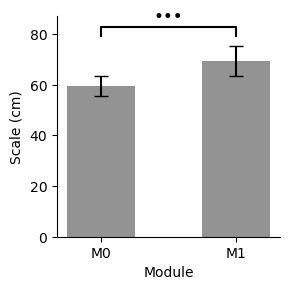

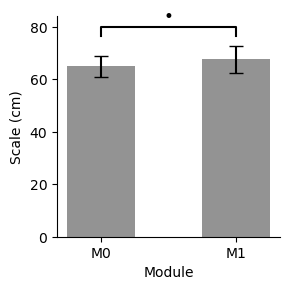

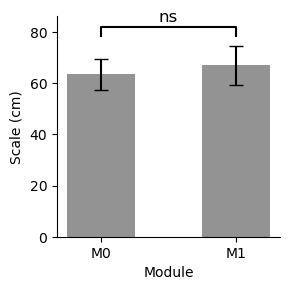

In [107]:
plot_run_module_bars(summary_df, stats_df, "Apr-05-2026-23-13-47")
plot_run_module_bars(summary_df, stats_df, "Apr-11-2026-20-05-03")
plot_run_module_bars(summary_df, stats_df, "Apr-12-2026-09-50-39")


In [222]:
def plot_run_scales_scatter_hist_kde(
    dt,
    model="tpc",
    n_cells=80,
    h=1.6,
    k_max=6,
    prominence=0.15,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from src.evaluation.module_eval import estimate_k_from_ksd

    path = f"../results/{model}/{dt}"

    # scales/scores in sorted-by-score order
    scales_cm, _, scores, unsrt_scores, _ = get_grid_scales_me_cm(
        dt, model=model, n_cells=n_cells, h=h
    )

    # module ids in sorted-by-score order
    cfg = json.load(open(f"{path}/configs.json", "r"))
    Ng = int(cfg["Ng"])
    n_module = int(cfg.get("n_module", 1))
    fracs = cfg.get("module_fracs", None)

    if fracs is None:
        counts = [Ng // n_module] * n_module
    else:
        fr = np.asarray(fracs, dtype=float)
        fr = fr / fr.sum()
        counts = np.floor(fr * Ng).astype(int)
        counts[-1] = Ng - counts[:-1].sum()
        counts = counts.tolist()

    sort_idx = np.argsort(unsrt_scores)[::-1]
    module_of_orig = np.empty(Ng, dtype=int)
    s = 0
    for m, c in enumerate(counts):
        module_of_orig[s:s+c] = m
        s += c
    module_idx_sorted = module_of_orig[sort_idx][:n_cells]

    # keep valid scales
    valid = np.isfinite(scales_cm) & (scales_cm > 0)
    scales = scales_cm[valid]
    mods = module_idx_sorted[valid]
    scs = scores[:n_cells][valid]

    # NEW: reorder x-axis by module, then by score within module
    order = np.lexsort((-scs, mods))
    scales_o = scales[order]
    mods_o = mods[order]
    x_o = np.arange(len(scales_o))

    # KDE/peaks from log-scales
    k_est, ksd = estimate_k_from_ksd(
        np.log(scales_o),
        k_max=k_max,
        prominence=prominence,
        grid_size=grid_size,
        bw_mode=bw_mode,
        exp_bw_a=exp_bw_a,
        exp_bw_b=exp_bw_b,
        exp_bw_min=exp_bw_min,
        exp_bw_max=exp_bw_max,
    )
    peak_log = ksd["grid"][ksd["peaks"]]
    peak_cm = np.exp(peak_log)

    # plot
    fig = plt.figure(figsize=(6, 4))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.4], wspace=0.05)
    ax_sc = fig.add_subplot(gs[0, 0])
    ax_hi = fig.add_subplot(gs[0, 1], sharey=ax_sc)

    cmap = plt.cm.get_cmap("tab20", max(2, n_module))
    for m in np.unique(mods_o):
        msk = mods_o == m
        ax_sc.scatter(x_o[msk], scales_o[msk], s=16, alpha=0.85, color=cmap(int(m)), label=f"M{int(m)}")

    # module boundaries
    boundaries = np.where(np.diff(mods_o) != 0)[0]
    for b in boundaries:
        ax_sc.axvline(b + 0.5, color="k", ls="--", lw=0.8, alpha=0.5)

    ax_sc.set_xlabel("Cell index")
    ax_sc.set_ylabel("Grid Scale (cm)")
    # ax_sc.set_title(f"{dt} | k_est={k_est}")
    ax_sc.legend(frameon=False, loc="best")
    ax_sc.grid(True, which="major", axis="both", alpha=0.25, linestyle="--")

    # rotated histogram + KDE (on scale axis)
    ax_hi.hist(scales_o, bins=10, orientation="horizontal", density=True, alpha=0.35, color="gray")
    s_grid = np.linspace(scales_o.min(), scales_o.max(), 400)
    dens_s = np.interp(np.log(s_grid), ksd["grid"], ksd["density"]) / s_grid
    ax_hi.plot(dens_s, s_grid, color="black", lw=2)

    peak_dens = ksd["density"][ksd["peaks"]]   # density at each detected peak (log-space KDE)
    for p_cm, d_pk in zip(peak_cm, peak_dens):
        ax_hi.axhline(p_cm, color="crimson", ls="--", lw=1, alpha=0.6)  # optional guide line
        ax_hi.plot(d_pk / p_cm, p_cm, "o", color="crimson", ms=5) 

    ax_hi.set_xlabel("Density")
    plt.setp(ax_hi.get_yticklabels(), visible=False)

    for ax in [ax_sc, ax_hi]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        "k_est": k_est,
        "peaks_cm": peak_cm,
        "ordered_scales_cm": scales_o,
        "ordered_modules": mods_o,
        "ksd": ksd,
    }


C:\Users\User\AppData\Local\Temp\ipykernel_48864\1637202485.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(2, n_module))
C:\Users\User\AppData\Local\Temp\ipykernel_48864\1637202485.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


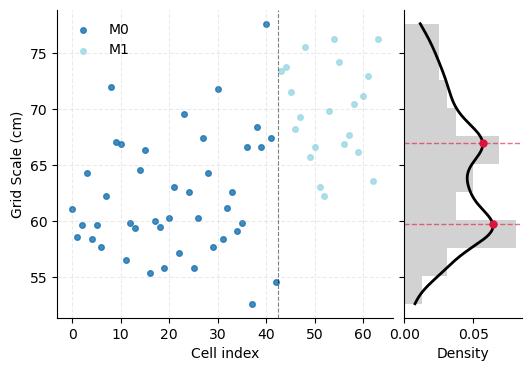

In [223]:
out = plot_run_scales_scatter_hist_kde(
    "Apr-05-2026-21-45-46", n_cells=64, h=1.6,
    prominence=0.05,
    grid_size=500,
    bw_mode="exp",
    exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)


## Run Config Summary (Network / Env / Epoch)

- `Mar-15-2026-21-18-53` (`small_network_path`)
  - Network size: `Ng=1024`, `Np=512`
  - Environment size: `box_width=1.6`, `box_height=1.6` (rectangle)
  - Training epochs: `n_epochs=100`

- `Mar-15-2026-23-02-50` (`large_network_path`)
  - Network size: `Ng=3072`, `Np=512`
  - Environment size: `box_width=1.6`, `box_height=1.6` (rectangle)
  - Training epochs: `n_epochs=100`

- `Mar-15-2026-19-34-28` (`large_env_network_path`)
  - Network size: `Ng=1024`, `Np=512`
  - Environment size: `box_width=4.0`, `box_height=4.0` (rectangle)
  - Training epochs: `n_epochs=100`

- `Mar-17-2026-19-52-39`
  - Network size: `Ng=2048`, `Np=512`
  - Environment size: `box_width=3.2`, `box_height=3.2` (rectangle)
  - Training epochs: `n_epochs=200`

- `Mar-22-2026-23-45-56`
  - Continue training in a larger 2.4x2.4 env from Mar-15-2026-21-18-53

- `Apr-04-2026-19-49-29`
  - Continue training in a larger 2.4x2.4 env from Mar-15-2026-23-02-50

### Key Differences
- Largest network: `Mar-15-2026-23-02-50` (`Ng=3072`).
- Largest environment: `Mar-15-2026-19-34-28` (`4.0 x 4.0`).
- Longest training: `Mar-17-2026-19-52-39` (`200` epochs).


In [3]:
from src.evaluation.module_eval import extract_sac_fields, grid_scale_stensola_like, top_cells_grid_scales
from src.evaluation import (
    top_cells_grid_scales,
    discreteness_curve_hist,
    module_discreteness_report,
    plot_module_discreteness_report,
    continuous_null_curve,
    estimate_k_from_ksd
)

In [4]:
small_path = "Mar-15-2026-21-18-53"
small_net_scores = np.load(f"../results/tpc/{small_path}/grid_scores.npy")
large_path = "Mar-15-2026-23-02-50"
large_net_scores = np.load(f"../results/tpc/{large_path}/grid_scores.npy")

# number of scores > threshold in each set
# make it a table
print("Threshold | Small Net | Large Net")
print("----------|-----------|----------")
for score in [0.8, 0.9, 1.0, 1.1, 1.2]:
    print(f"{score} | {np.sum(small_net_scores > score)} | {np.sum(large_net_scores > score)}")

Threshold | Small Net | Large Net
----------|-----------|----------
0.8 | 86 | 147
0.9 | 54 | 97
1.0 | 37 | 51
1.1 | 18 | 33
1.2 | 4 | 11


### Scale computation

How to detect grid cells: We generate a shuffled null by circularly time-shifting each cell’s activity with np.roll (keeping firing statistics unchanged) so firing values are reassigned to different positions, which disrupts true spatial alignment and therefore breaks hexagonal grid structure on average. We then generate 100 such disrupted grid maps. Grid cells with score > 95 percentile of the disrupted score distribution is classified as a grid cell

In [5]:
def module_index_by_sorted_score_custom(run_path):
    """
    Reads module fractions from configs.json and returns module index
    aligned to sorted-score order.
    """
    with open(f"{run_path}/configs.json", "r") as f:
        cfg = json.load(f)

    n_module_cfg = int(cfg.get("n_module", 1))
    module_fracs = cfg.get("module_fracs", None)

    # If not explicitly stored, fall back to equal fractions.
    if module_fracs is None:
        module_fracs = np.ones(n_module_cfg, dtype=float) / n_module_cfg
    else:
        module_fracs = np.asarray(module_fracs, dtype=float)

    if module_fracs.ndim != 1 or module_fracs.size == 0:
        raise ValueError("module_fracs in config must be a non-empty 1D list/array.")
    if len(module_fracs) != n_module_cfg:
        raise ValueError(
            f"len(module_fracs)={len(module_fracs)} does not match n_module={n_module_cfg} in config."
        )
    if np.any(module_fracs < 0):
        raise ValueError("module_fracs must be non-negative.")
    if np.allclose(module_fracs.sum(), 0):
        raise ValueError("module_fracs sum must be > 0.")

    module_fracs = module_fracs / module_fracs.sum()

    print(f"n_module: {n_module_cfg}")
    print(f"module_fracs (normalized): {module_fracs.tolist()}")

    unsrt_scores = np.asarray(np.load(f"{run_path}/unsrt_grid_scores.npy")).reshape(-1)
    Ng = len(unsrt_scores)

    # sorted position -> original index
    sort_idx = np.argsort(unsrt_scores)[::-1]

    # original index -> module id from fractions
    counts = np.floor(module_fracs * Ng).astype(int)
    counts[-1] = Ng - counts[:-1].sum()  # exact total
    print(f"module_counts: {counts.tolist()} (Ng={Ng})")

    module_of_orig = np.empty(Ng, dtype=int)
    start = 0
    for m, c in enumerate(counts):
        end = start + c
        module_of_orig[start:end] = m
        start = end

    # module ids in sorted-score order
    module_idx_sorted = module_of_orig[sort_idx]
    return module_idx_sorted


In [6]:
def get_grid_scales_cm(dt, model='tpc', n_cells=80, corr_thresh=0.2, h=1.6, connectivity=8, min_area=5, method='stensola'):
    path = f"../results/{model}/{dt}"
    sacs = np.load(f"{path}/sac.npy") # descending order of grid score, shape (n_cells, height, width)
    scores = np.load(f"{path}/grid_scores.npy") # descending order of grid score
    unsrt_scores = np.load(f"{path}/unsrt_grid_scores.npy")

    # check if is_grid.npy exists
    is_grid_path = os.path.join(path, "is_grid.npy")
    if os.path.exists(is_grid_path):
        is_grid_unsorted = np.load(is_grid_path)  # unsorted
        sort_idx = np.argsort(unsrt_scores)[::-1]
        is_grid_sorted = is_grid_unsorted[sort_idx]

        # select the first False's index as the threshold for grid cells
        example_idx = np.where(is_grid_sorted == False)[0][0] - 1
        print(f"Grid cell threshold index: {example_idx}, grid score threshold: {scores[example_idx]:.3f}")
    else:
        print("is_grid.npy not found, not using Stensola-like method for grid cell determination.")

    if method == 'stensola':
        scales_px = top_cells_grid_scales(
            sacs, scores, n_cells=n_cells, corr_thresh=corr_thresh, connectivity=connectivity, min_area=min_area
        )
    else:
        scales_px = []
        for sac in sacs[:n_cells]:
            peaks = find_local_maxima(sac)
            center_peak = find_global_maxima(sac)   
            scale_px = get_grid_scale(peaks, center_peak, method='average')
            scales_px.append(scale_px)
        scales_px = np.array(scales_px)
    # convert to cm
    rate_map_h = (sacs[0].shape[0] + 1) / 2
    bin_size = h / rate_map_h # m per pixel
    scales_cm = scales_px * bin_size * 100  # convert to cm
    return scales_cm, scales_px, scores, unsrt_scores, sacs


In [7]:
def plot_grid_scales_me(scales_cm, scores, unsrt_scores, sacs, range_indices, top_k=6, n_examples=3):
    def _top_cells(range_inds):
        if len(range_inds) == 0:
            return []
        sorted_idx = np.argsort(scores[range_inds])[::-1]
        return [int(range_inds[i]) for i in sorted_idx[:n_examples]]

    n_rows = len(range_indices)
    fig, ax = plt.subplots(n_rows, n_examples, figsize=(3 * n_examples, 3 * n_rows), squeeze=False)

    orig_idx_to_sorted_idx = np.argsort(unsrt_scores)[::-1]
    
    for i, range_inds in enumerate(range_indices):
        top_cells = _top_cells(range_inds)
        for j in range(n_examples):
            axes = ax[i][j]
            if j >= len(top_cells):
                axes.axis("off")
                continue

            cell_idx = top_cells[j]
            orig_idx = orig_idx_to_sorted_idx[cell_idx]
            example_sac = sacs[cell_idx]
            center_peak = find_global_maxima(example_sac)
            peaks = find_local_maxima(example_sac)
            peaks = [peak for peak in peaks if not np.array_equal(peak, center_peak)]
            peaks = sorted(peaks, key=lambda p: np.linalg.norm(np.array(p) - np.array(center_peak)))[:top_k]

            axes.imshow(example_sac, cmap="viridis", interpolation="gaussian")
            axes.plot(center_peak[1], center_peak[0], "ro")
            for peak in peaks:
                axes.plot(peak[1], peak[0], "kx")
                axes.plot([center_peak[1], peak[1]], [center_peak[0], peak[0]], "w--")

            axes.set_title(
                f"Range {i+1} top{j+1}: idx {cell_idx} (orig {orig_idx})\n"
                f"Scale: {scales_cm[cell_idx]:.1f} cm, Score: {scores[cell_idx]:.3f}"
            )
            axes.set_xticks([])
            axes.set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_grid_scales_stensola(scales_cm, scores, sacs, range_indices, corr_thresh=0.2, connectivity=8, min_area=5):
    def _plot_grid_scale_for_range(range_inds):
        if len(range_inds) > 0:
            max_score_idx = np.argmax(scores[range_inds])
            best_cell = range_inds[max_score_idx]
            example_sac = sacs[best_cell]
            fields, labels, binary = extract_sac_fields(
                example_sac, corr_thresh=corr_thresh, connectivity=connectivity, min_area=min_area
            )
            scale_results = grid_scale_stensola_like(fields, example_sac.shape)
            return best_cell, scale_results, example_sac
        else:
            return None, None, None

    fig, ax = plt.subplots(len(range_indices), 1, figsize=(3, 3 * len(range_indices)))
    for i, range_inds in enumerate(range_indices):
        best_cell, scale_results, example_sac = _plot_grid_scale_for_range(range_inds)
        ax[i].imshow(example_sac, cmap="viridis", interpolation="gaussian")
        for j, f in enumerate(scale_results["surrounding_six"]):
            com = f["com"]
            ax[i].plot(com[1], com[0], "bo")  # surrounding COMs
            ax[i].plot([scale_results["midpoint"][1], com[1]], [scale_results["midpoint"][0], com[0]], "w-")  # line to midpoint
            dist = scale_results["distances_px"][j]
            ax[i].text(com[1]+2, com[0]+2, f"{dist:.1f}px", color="white", fontsize=8)
        ax[i].set_title(f"Scale: {scales_cm[best_cell]:.1f} cm; Score: {scores[best_cell]:.3f}")
    plt.tight_layout()
    plt.show()

In [ ]:
def _wrap_deg(x):
    """Wrap angle to (-180, 180]."""
    return (x + 180.0) % 360.0 - 180.0

def label_axes_stensola(center_peak, local_peaks, top_k=6):
    """
    Implements:
    - pick inner-ring peaks (nearest top_k to center)
    - Axis 1: peak with minimal absolute angle to horizontal reference (0 deg)
    - Axis 2/3: two peaks with minimal |angular distance| to Axis 1
      (Axis 2 = most positive, Axis 3 = most negative relative to Axis 1)
    Returns dict with axis indices, vectors, and angles.
    """
    c = np.asarray(center_peak, dtype=float)

    # remove center if present
    ring = [np.asarray(p, dtype=float) for p in local_peaks if not np.array_equal(p, c)]
    if len(ring) < 3:
        return None

    # inner ring = nearest peaks
    ring = sorted(ring, key=lambda p: np.linalg.norm(p - c))[:top_k]

    # vectors center->peak
    vecs = [p - c for p in ring]  # (dr, dc)

    # angle wrt fixed horizontal reference (rightward), CCW-positive:
    # use -dr so upward is positive y in standard math coords
    ang = np.array([np.degrees(np.arctan2(-v[0], v[1])) for v in vecs], dtype=float)
    ang = np.array([_wrap_deg(a) for a in ang])

    # Axis 1: closest to 0 deg in absolute angular distance
    i1 = int(np.argmin(np.abs(ang)))
    a1 = ang[i1]

    # angular distances to Axis 1 (signed, wrapped)
    d = np.array([_wrap_deg(a - a1) for a in ang], dtype=float)
    d[i1] = np.nan

    # closest positive and negative
    pos_idx = np.where(d > 0)[0]
    neg_idx = np.where(d < 0)[0]
    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return None

    i2 = int(pos_idx[np.argmin(np.abs(d[pos_idx]))])  # most positive closest
    i3 = int(neg_idx[np.argmin(np.abs(d[neg_idx]))])  # most negative closest

    return {
        "axis1_idx": i1, "axis2_idx": i2, "axis3_idx": i3,
        "axis1_angle_deg": ang[i1],
        "axis2_angle_deg": ang[i2],
        "axis3_angle_deg": ang[i3],
        "axis1_vec": vecs[i1], "axis2_vec": vecs[i2], "axis3_vec": vecs[i3],
        "all_angles_deg": ang, "all_vecs": vecs, "ring_peaks": ring
    }

In [242]:
def plot_orientation_examples(
    dt,
    model="tpc",
    n_cells=200,
    n_examples=6,
    top_k=6,
):
    """
    Show example SACs with detected center/ring peaks and estimated orientation.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    oris_deg, scores, _, sacs = get_grid_orientations_me_deg(
        dt, model=model, n_cells=n_cells, top_k=top_k
    )

    valid_idx = np.where(np.isfinite(oris_deg))[0]
    if len(valid_idx) == 0:
        print("No valid orientation estimates.")
        return

    # pick evenly spaced examples among valid cells
    pick = np.linspace(0, len(valid_idx)-1, min(n_examples, len(valid_idx))).astype(int)
    ex_idx = valid_idx[pick]

    fig, axes = plt.subplots(1, len(ex_idx), figsize=(3.2*len(ex_idx), 3.2), squeeze=False)
    axes = axes[0]

    for ax, i in zip(axes, ex_idx):
        sac = sacs[i]
        center = np.array(find_global_maxima(sac), dtype=float)
        peaks = find_local_maxima(sac)
        ring = [np.array(p, dtype=float) for p in peaks if not np.array_equal(p, center)]
        ring = sorted(ring, key=lambda p: np.linalg.norm(p - center))[:top_k]

        # orientation line: angle in [0,60), draw one direction + opposite (same axis)
        theta = np.deg2rad(oris_deg[i])
        v = np.array([np.sin(theta), np.cos(theta)])  # (dr, dc)
        L = min(sac.shape) * 0.22

        p1 = center + L * v
        p2 = center - L * v

        ax.imshow(sac, cmap="viridis", interpolation="gaussian")
        ax.plot(center[1], center[0], "ro", ms=5, label="center")
        for p in ring:
            ax.plot(p[1], p[0], "wx", ms=5, mew=1.2)

        ax.plot([p1[1], p2[1]], [p1[0], p2[0]], color="cyan", lw=2)

        ax.set_title(f"cell {i}\nori={oris_deg[i]:.1f}°\nscore={scores[i]:.3f}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()


## Single model - key cells to run; replace the path with model run path

In [236]:
n_cells = 64
corr_thresh = 0.25
connectivity = 8
min_area = 5
h = 1.6
model = 'tpc'
path = 'Apr-05-2026-21-45-46'

[0.7 0.3]
block mean |W|:
[[0.036439 0.      ]
 [0.       0.075888]]


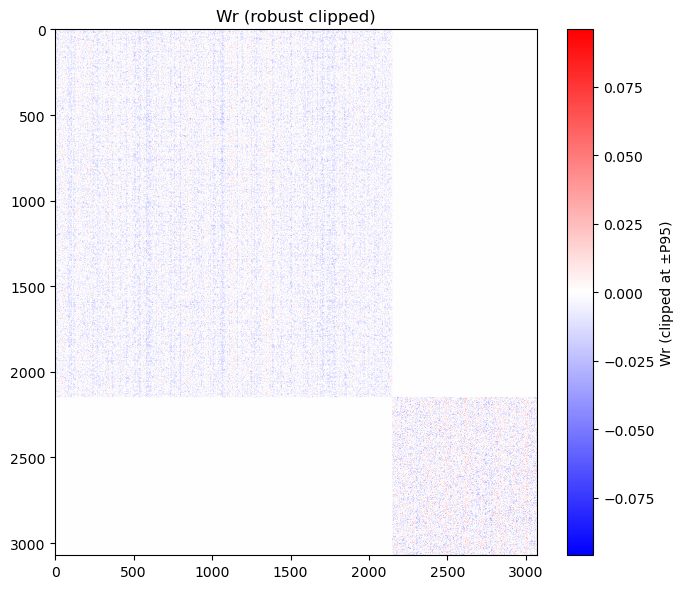

In [237]:
# plt weights of the model
import json
import numpy as np

# W is your recurrent weight matrix [Ng, Ng]
# run_dir is already defined
run_dir =f"../results/{model}/{path}"  # your path
with open(f"{run_dir}/configs.json", "r") as f:
    cfg = json.load(f)

n_module = int(cfg.get("n_module", 1))
fracs = np.asarray(cfg.get("module_fracs", [1.0]), dtype=float)
fracs = fracs / fracs.sum()
print(fracs)

ckpt = torch.load(f"{run_dir}/models/most_recent_model.pth", map_location="cpu")

if model == 'tpc':
    Wr = ckpt["model"]["Wr.weight"].cpu().numpy()
    W = Wr  # [Ng, Ng]
elif model == 'rnn':
    Wr = ckpt["RNN.weight_hh_l0"].cpu().numpy()
    W = Wr  # [Ng, Ng]

Ng = W.shape[0]
counts = np.floor(fracs * Ng).astype(int)
counts[-1] = Ng - counts[:-1].sum()

starts = np.cumsum(np.r_[0, counts[:-1]])
ends = starts + counts

block_mean_abs = np.zeros((n_module, n_module))
for i in range(n_module):
    for j in range(n_module):
        block = W[starts[i]:ends[i], starts[j]:ends[j]]
        block_mean_abs[i, j] = np.mean(np.abs(block))

print("block mean |W|:")
print(np.round(block_mean_abs, 6))




# 1) Clip to robust percentile range (ignore extreme outliers)
p = 95
v = np.percentile(np.abs(W), p)

plt.figure(figsize=(7,6))
plt.imshow(np.clip(W, -v, v), cmap="bwr", vmin=-v, vmax=v, aspect="auto")
plt.colorbar(label=f"Wr (clipped at ±P{p})")
plt.title("Wr (robust clipped)")
plt.tight_layout()
plt.show()

# 2) Symmetric log scale to reveal small + large values together
# from matplotlib.colors import SymLogNorm
# plt.figure(figsize=(7,6))
# plt.imshow(
#     W,
#     cmap="bwr",
#     norm=SymLogNorm(linthresh=1e-3, linscale=1.0,
#                     vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W))),
#     aspect="auto",
# )
# plt.colorbar(label="Wr (symlog)")
# plt.title("Wr (symlog)")
# plt.tight_layout()
# plt.show()

### Scale based on Stensola's method - ignore this.

In [10]:
scales_cm, scales_px, scores, unsrt_scores, sacs = get_grid_scales_cm(
    path, n_cells=n_cells, corr_thresh=corr_thresh, h=1.6, connectivity=connectivity, min_area=min_area, method='stensola'
)

is_grid.npy not found, not using Stensola-like method for grid cell determination.


Text(0, 0.5, 'Scale (cm)')

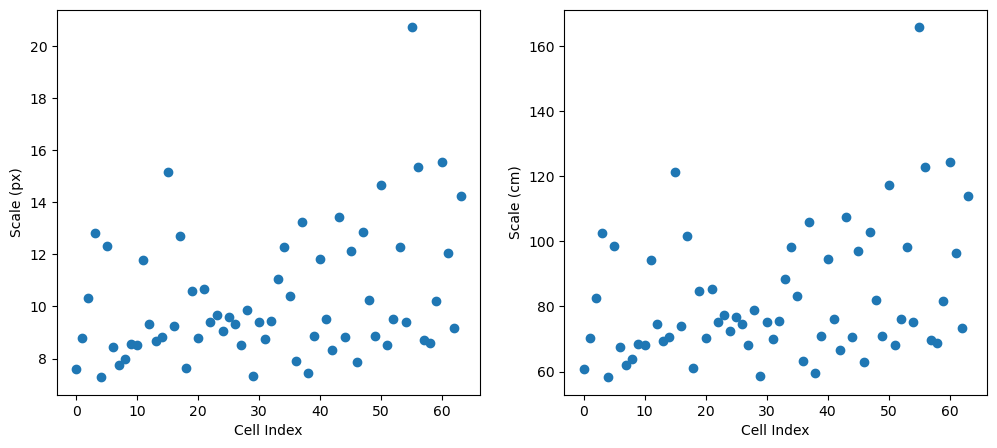

In [269]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(np.arange(scales_px.shape[0]), scales_px)
ax[0].set_xlabel("Cell Index")
ax[0].set_ylabel("Scale (px)")

ax[1].scatter(np.arange(scales_cm.shape[0]), scales_cm)
ax[1].set_xlabel("Cell Index")
ax[1].set_ylabel("Scale (cm)")

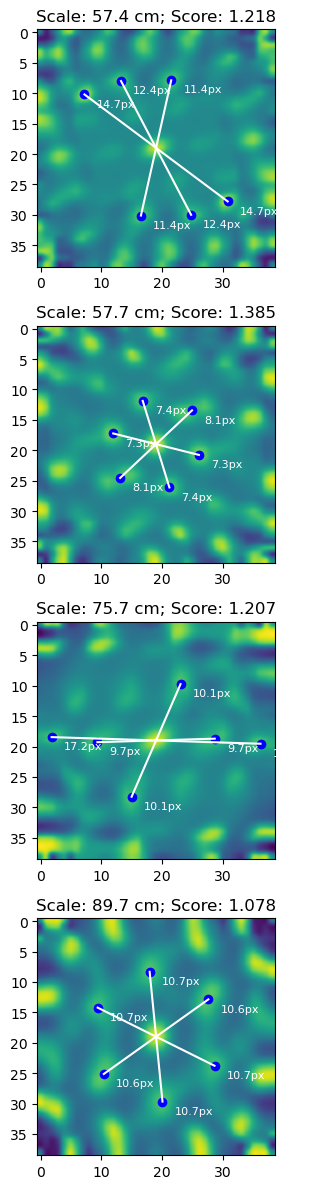

In [277]:
# examples of sacs with different scales - percentile-based selection
scales_sorted = np.sort(scales_cm)      
p10_val1 = scales_sorted[int(len(scales_sorted) * 0.10)]
p75_val1 = scales_sorted[int(len(scales_sorted) * 0.75)]
p95_val1 = scales_sorted[int(len(scales_sorted) * 0.95)]

cell_indices = [
    np.where(scales_cm <= p10_val1)[0], 
    np.where((scales_cm > p10_val1) & (scales_cm <= p75_val1))[0],
    np.where((scales_cm > p75_val1) & (scales_cm <= p95_val1))[0],
    np.where(scales_cm > p95_val1)[0]
]

plot_grid_scales_stensola(
    scales_cm, scores, sacs, cell_indices, corr_thresh=corr_thresh, connectivity=connectivity, min_area=min_area)


is_grid.npy not found, not using Stensola-like method for grid cell determination.


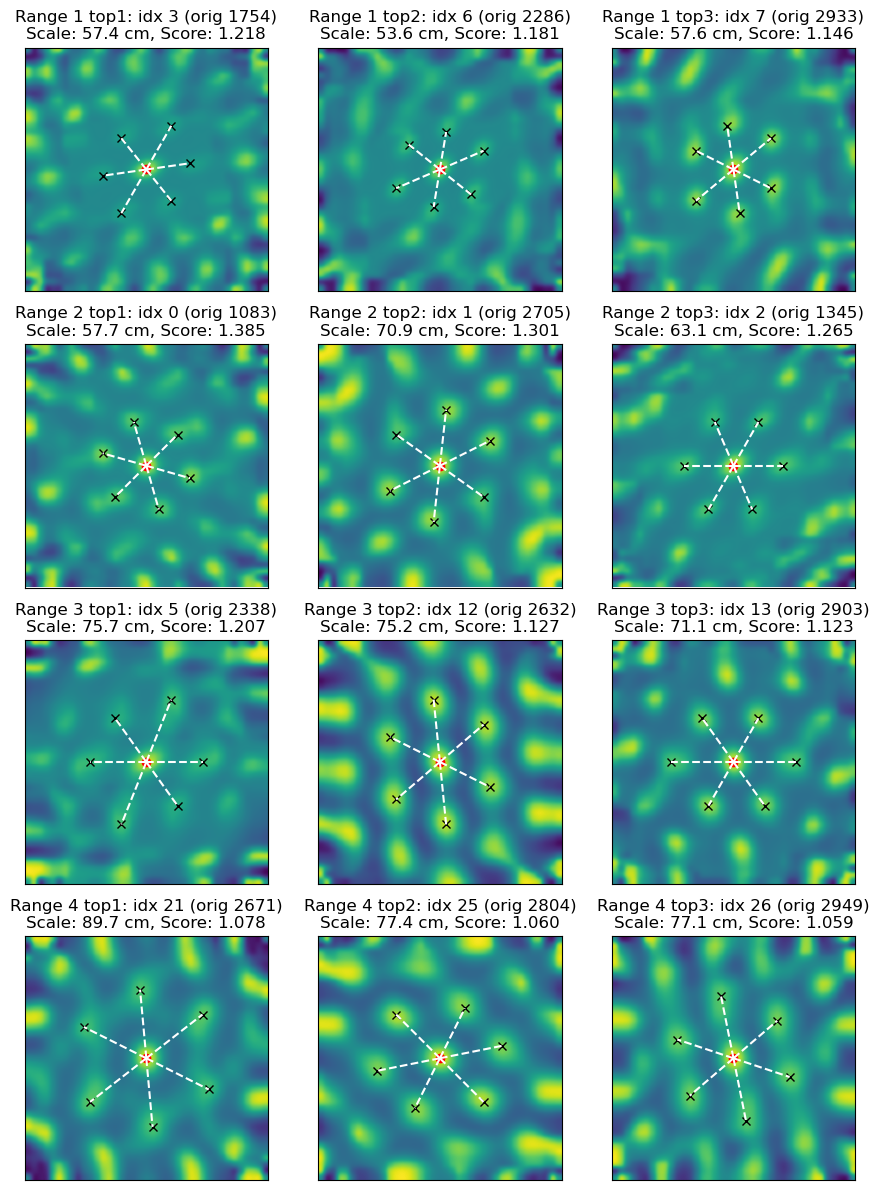

In [273]:
scales_cm, scales_px, scores, unsrt_scores, sacs = get_grid_scales_cm(
    path, n_cells=n_cells, corr_thresh=corr_thresh, h=1.6, connectivity=connectivity, min_area=min_area, method='me'
)
# examples of sacs with different scales - percentile-based selection
scales_sorted = np.sort(scales_cm)      
p10_val1 = scales_sorted[int(len(scales_sorted) * 0.10)]
p75_val1 = scales_sorted[int(len(scales_sorted) * 0.75)]
p95_val1 = scales_sorted[int(len(scales_sorted) * 0.95)]

cell_indices = [
    np.where(scales_cm <= p10_val1)[0], 
    np.where((scales_cm > p10_val1) & (scales_cm <= p75_val1))[0],
    np.where((scales_cm > p75_val1) & (scales_cm <= p95_val1))[0],
    np.where(scales_cm > p95_val1)[0]
]

plot_grid_scales_me(
    scales_cm, scores, unsrt_scores, sacs, cell_indices)


### Scale based on local maxima

In [238]:
scales_cm, scales_px, scores, unsrt_scores,sacs = get_grid_scales_cm(
    path, 
    model=model,
    n_cells=n_cells, 
    corr_thresh=corr_thresh, h=h, connectivity=connectivity, min_area=min_area, method='me'
)
scales_sorted = np.sort(scales_cm)      
p10_val1 = scales_sorted[int(len(scales_sorted) * 0.10)]
p75_val1 = scales_sorted[int(len(scales_sorted) * 0.75)]
p95_val1 = scales_sorted[int(len(scales_sorted) * 0.95)]
cell_indices = [
    np.where(scales_cm <= p10_val1)[0], 
    np.where((scales_cm > p10_val1) & (scales_cm <= p75_val1))[0],
    np.where((scales_cm > p75_val1) & (scales_cm <= p95_val1))[0],
    np.where(scales_cm > p95_val1)[0]
]

is_grid.npy not found, not using Stensola-like method for grid cell determination.


In [239]:
orientations_deg, scores, unsrt_scores, sacs = get_grid_orientations_me_deg(
    path, model=model, n_cells=n_cells, top_k=6
)

n_module: 2
module_fracs (normalized): [0.7, 0.3]
module_counts: [2150, 922] (Ng=3072)


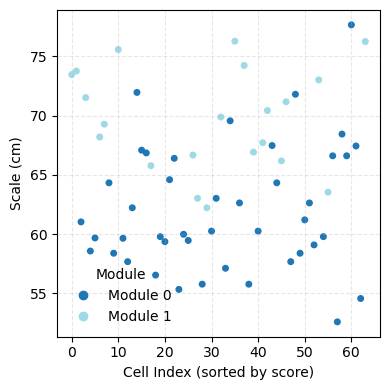

In [227]:
module_idx = module_index_by_sorted_score_custom(f"../results/{model}/{path}")

fig, ax = plt.subplots(figsize=(4, 4))
sc = ax.scatter(
    np.arange(scales_cm.shape[0]),
    scales_cm,
    c=module_idx[:n_cells],
    cmap="tab20",
    s=16
)

ax.set_xlabel("Cell Index (sorted by score)")
ax.set_ylabel("Scale (cm)")
ax.grid(True, linestyle="--", alpha=0.3)

handles, _ = sc.legend_elements(prop="colors")
labels = [f"Module {m}" for m in np.unique(module_idx[:n_cells])]
ax.legend(handles, labels, title="Module", loc="best", frameon=False)

plt.tight_layout()
plt.show()

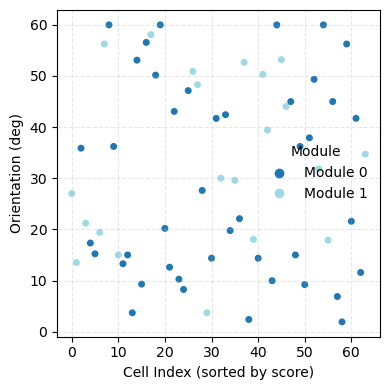

In [241]:
# visualize orientations colored by module
fig, ax = plt.subplots(figsize=(4, 4))
sc = ax.scatter(
    np.arange(orientations_deg.shape[0]),
    orientations_deg,
    c=module_idx[:n_cells],
    cmap="tab20",
    s=16
)
ax.set_xlabel("Cell Index (sorted by score)")
ax.set_ylabel("Orientation (deg)")
ax.grid(True, linestyle="--", alpha=0.3)
handles, _ = sc.legend_elements(prop="colors")
labels = [f"Module {m}" for m in np.unique(module_idx[:n_cells])]
ax.legend(handles, labels, title="Module", loc="best", frameon=False)
plt.tight_layout()
plt.show()

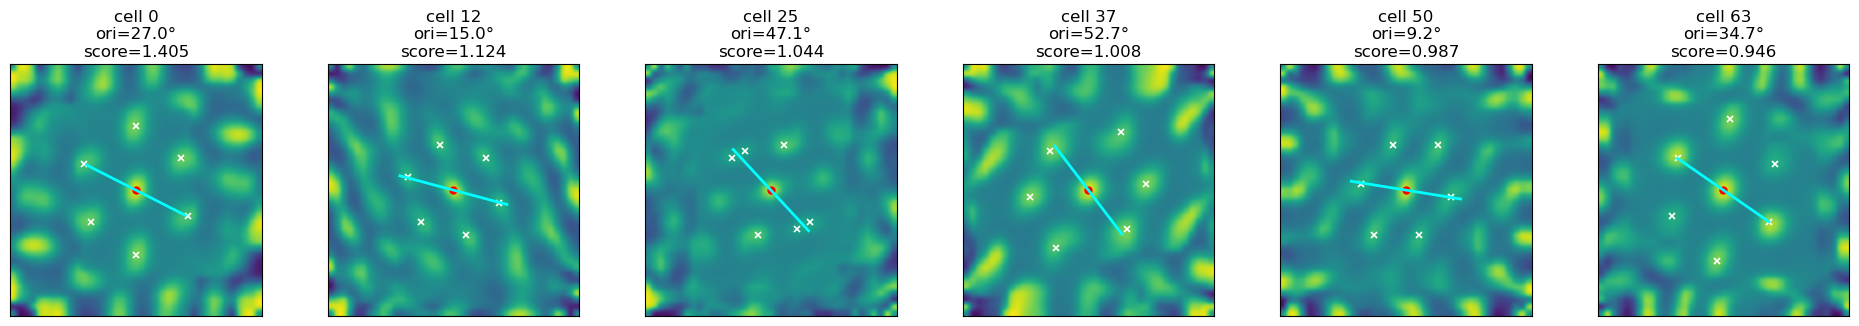

In [243]:
plot_orientation_examples(
    path, model=model, n_cells=n_cells, n_examples=6, top_k=6
)

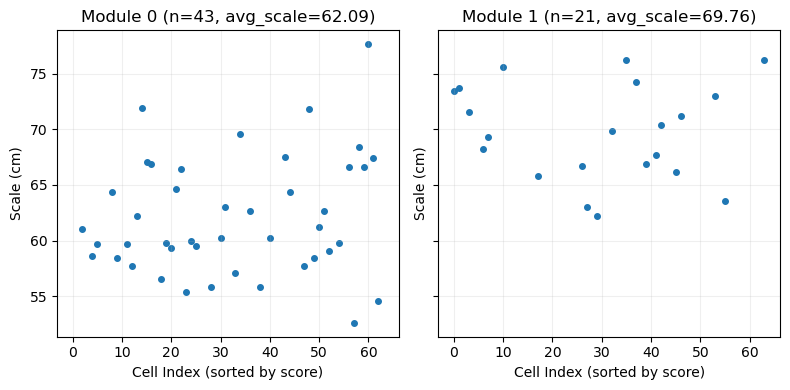

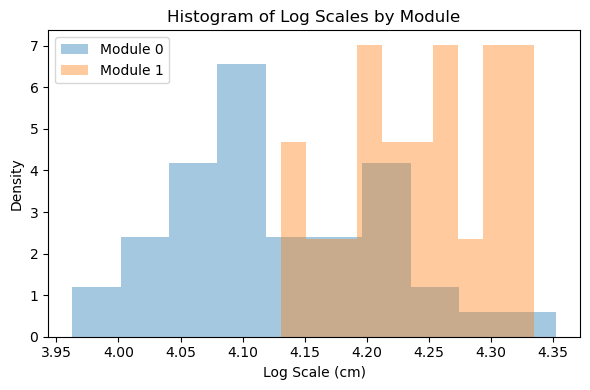

In [228]:
mods = module_idx[:n_cells]
x = np.arange(scales_cm.shape[0])
unique_mods = np.unique(mods)

fig, axes = plt.subplots(1, len(unique_mods), figsize=(4*len(unique_mods), 4), sharex=True, sharey=True)
if len(unique_mods) == 1:
    axes = [axes]

for ax, m in zip(axes, unique_mods):
    mask = (mods == m)
    ax.scatter(x[mask], scales_cm[mask], s=16, label=f"Module {m}")
    ax.set_ylabel("Scale (cm)")
    # calculate number of cells in this module and average scale
    n_cells_m = np.sum(mask)
    avg_scale_m = np.mean(scales_cm[mask])
    ax.set_title(f"Module {m} (n={n_cells_m}, avg_scale={avg_scale_m:.2f})")
    ax.grid(alpha=0.2)
    ax.set_xlabel("Cell Index (sorted by score)")
plt.tight_layout()
plt.show()

# plot the histograms of scales for each module in a single figure with different colors
plt.figure(figsize=(6,4))
for m in unique_mods:
    mask = (mods == m)
    plt.hist(np.log(scales_cm[mask]), bins=10, density=True, alpha=0.4, label=f"Module {m}")
plt.xlabel("Log Scale (cm)")
plt.ylabel("Density")
plt.title("Histogram of Log Scales by Module")
plt.legend()
plt.tight_layout()
plt.show()


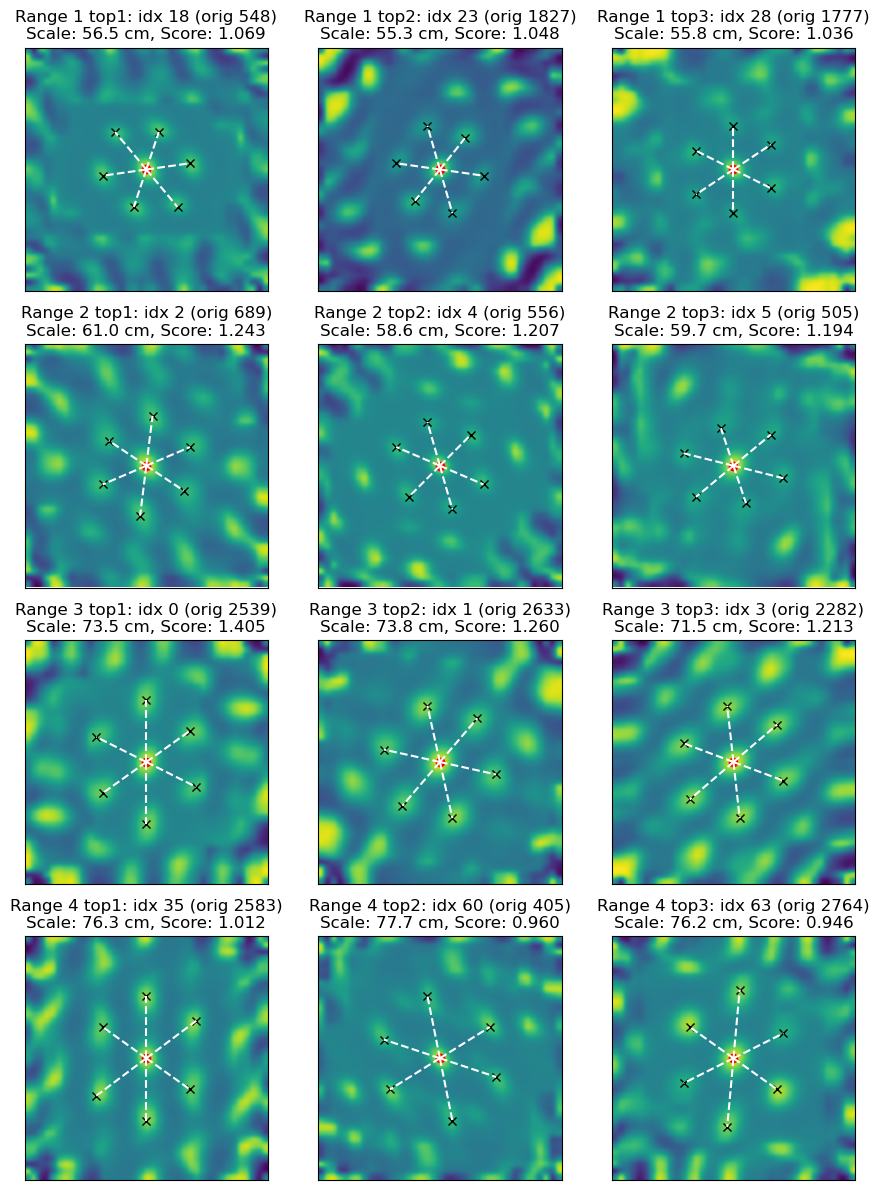

In [229]:
plot_grid_scales_me(scales_cm, scores, unsrt_scores, sacs, cell_indices)

### Scale distribution curve fitting

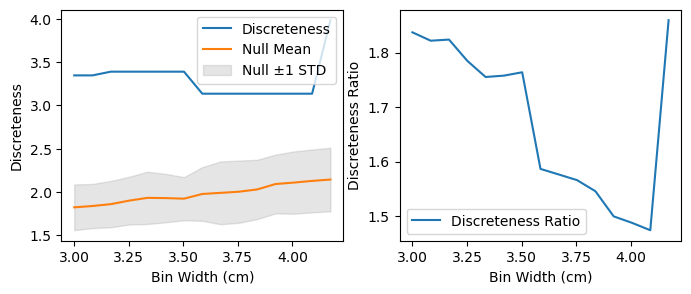

In [230]:
#histogram of scales - follow Stensola's bin widths
hi = (np.max(scales_cm) - np.min(scales_cm)) / 6
lo = 3
# discreteness score is the std of counts in each bin - higher means more discrete i.e. more 0s and more counts in a few bins
bin_widths = np.linspace(lo, hi, 15)
discreteness = discreteness_curve_hist(scales_cm, bin_widths)

# null distribution by adding random noise to the scales and recomputing discreteness scores
'''For each shuffle, add independent uniform jitter to every spacing:
    ``x_i + U(-0.5 * min(x), +0.5 * min(x))``. This preserves overall
    distribution shape while removing local discontinuities, as described
    in the Stensola supplementary methods.
'''
null_mean, null_std = continuous_null_curve(scales_cm, bin_widths, n_shuffle=100, random_state=0)
discreteness_ratio = discreteness / (null_mean + 1e-12)

plt.figure(figsize=(8,3))
plt.subplot(1, 2, 1)
plt.plot(bin_widths, discreteness, label="Discreteness")
plt.plot(bin_widths, null_mean, label="Null Mean")
plt.fill_between(bin_widths, null_mean - null_std, null_mean + null_std, color="gray", alpha=0.2, label="Null ±1 STD")
plt.xlabel("Bin Width (cm)")
plt.ylabel("Discreteness")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bin_widths, discreteness_ratio, label="Discreteness Ratio")
plt.xlabel("Bin Width (cm)")
plt.ylabel("Discreteness Ratio")
plt.legend()
plt.show()

In [233]:
k_est, ksd = estimate_k_from_ksd(
    np.log(scales_cm), k_max=6, prominence=0.15, grid_size=500,
    bw_mode='exp', exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)
k_est, ksd['peaks']

(2, array([162, 310], dtype=int64))

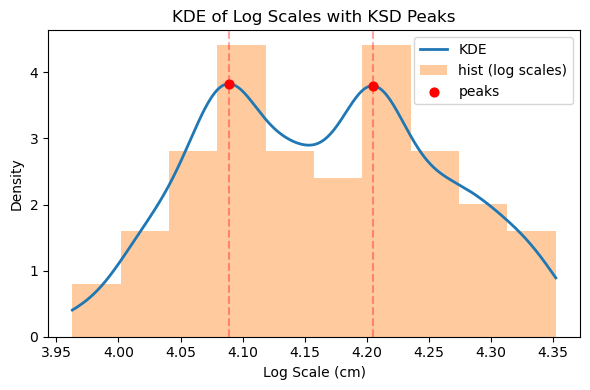

In [234]:
# kde fitting
from scipy.stats import gaussian_kde

grid = ksd["grid"]
dens = ksd["density"]
peaks = ksd["peaks"]

plt.figure(figsize=(6,4))
plt.plot(grid, dens, lw=2, label="KDE")
plt.hist(np.log(scales_cm), bins=10, density=True, alpha=0.4, label="hist (log scales)")

# plot peaks on KDE curve
plt.scatter(grid[peaks], dens[peaks], c="red", s=40, zorder=3, label="peaks")
for i, p in enumerate(peaks):
    plt.axvline(grid[p], color="red", ls="--", alpha=0.35)

plt.xlabel("Log Scale (cm)")
plt.ylabel("Density")
plt.title("KDE of Log Scales with KSD Peaks")
plt.legend()
plt.tight_layout()
plt.show()


21


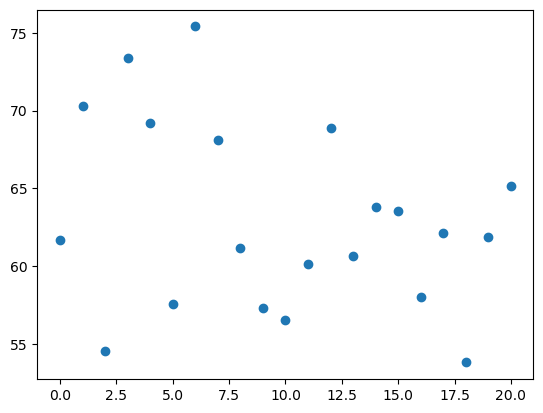

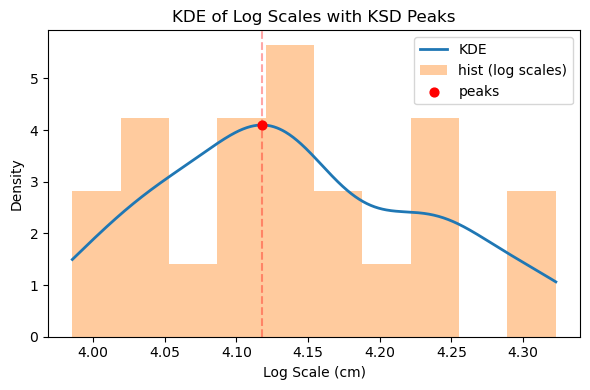

In [158]:
scales_cm0 = scales_cm[module_idx[:n_cells] == 1]
print(len(scales_cm0))
plt.scatter(np.arange(len(scales_cm0)), scales_cm0)
k_est, ksd = estimate_k_from_ksd(
    np.log(scales_cm0), k_max=6, prominence=0.15, grid_size=500,
    bw_mode='exp', exp_bw_a=0.5,
    exp_bw_b=0.01,
    exp_bw_min=0.02,
    exp_bw_max=1.0,
)
k_est, ksd['peaks']

from scipy.stats import gaussian_kde

grid = ksd["grid"]
dens = ksd["density"]
peaks = ksd["peaks"]

plt.figure(figsize=(6,4))
plt.plot(grid, dens, lw=2, label="KDE")
plt.hist(np.log(scales_cm0), bins=10, density=True, alpha=0.4, label="hist (log scales)")

# plot peaks on KDE curve
plt.scatter(grid[peaks], dens[peaks], c="red", s=40, zorder=3, label="peaks")
for i, p in enumerate(peaks):
    plt.axvline(grid[p], color="red", ls="--", alpha=0.35)

plt.xlabel("Log Scale (cm)")
plt.ylabel("Density")
plt.title("KDE of Log Scales with KSD Peaks")
plt.legend()
plt.tight_layout()
plt.show()


## Comparisons

In [178]:
model_tpc = 'tpc'
model_rnn = 'rnn'
n_cells = 64
path0 = 'Mar-15-2026-23-02-50'
path1 = 'Apr-05-2026-14-42-41'
scales_cm0, scales_px0, scores0, unsrt_scores0, sacs0 = get_grid_scales_cm(
    path0, 
    model=model_tpc,
    n_cells=n_cells, 
    corr_thresh=corr_thresh, h=1.6, connectivity=connectivity, min_area=min_area, method='me'
)
scales_cm1, scales_px1, scores1, unsrt_scores1, sacs1 = get_grid_scales_cm(
    path1,
    model=model_rnn,
    n_cells=n_cells,
    corr_thresh=corr_thresh, h=1.6, connectivity=connectivity, min_area=min_area, method='me'
)

is_grid.npy not found, not using Stensola-like method for grid cell determination.
is_grid.npy not found, not using Stensola-like method for grid cell determination.


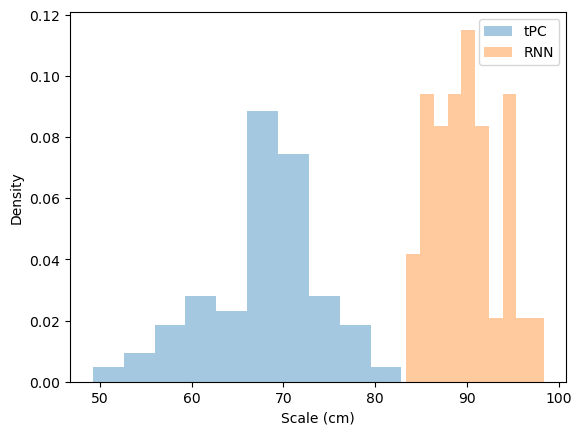

In [182]:
plt.hist(scales_cm0, bins=10, density=True, alpha=0.4, label="tPC")
plt.hist(scales_cm1, bins=10, density=True, alpha=0.4, label="RNN")
plt.xlabel("Scale (cm)")
plt.ylabel("Density")
plt.legend()